In [1]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [175]:
with open("D:\ds9.reg", "r") as f:
    content = f.read()

print(content)

# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
icrs
circle(273.1722669,64.1051539,15.966")
circle(273.1195623,64.1244674,9.067")



<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_19372\2110435709.py:1: SyntaxWarning: invalid escape sequence '\d'
  with open("D:\ds9.reg", "r") as f:


In [2]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [25]:
df_total = pd.read_pickle('../../all_fluxes_north.pkl')

In [141]:
df_total.columns

Index(['id', 'tile_index', 'ra', 'dec', 'FWHM', 'point_source_probability_mer',
       'FLUX_NIR-H_0.5FWHM', 'FLUXERR_NIR-H_0.5FWHM', 'FLUX_CFIS-R_0.5FWHM',
       'FLUXERR_CFIS-R_0.5FWHM', 'FLUX_NIR-Y_0.5FWHM', 'FLUXERR_NIR-Y_0.5FWHM',
       'FLUX_CFIS-U_0.5FWHM', 'FLUXERR_CFIS-U_0.5FWHM', 'FLUX_NIR-J_0.5FWHM',
       'FLUXERR_NIR-J_0.5FWHM', 'FLUX_PANSTARRS-I_0.5FWHM',
       'FLUXERR_PANSTARRS-I_0.5FWHM', 'FLUX_VIS_0.5FWHM',
       'FLUXERR_VIS_0.5FWHM', 'FLUX_WISHES-Z_0.5FWHM',
       'FLUXERR_WISHES-Z_0.5FWHM', 'FLUX_WISHES-G_0.5FWHM',
       'FLUXERR_WISHES-G_0.5FWHM', 'FLUX_NIR-J_1FWHM', 'FLUXERR_NIR-J_1FWHM',
       'FLUX_CFIS-U_1FWHM', 'FLUXERR_CFIS-U_1FWHM', 'FLUX_NIR-H_1FWHM',
       'FLUXERR_NIR-H_1FWHM', 'FLUX_CFIS-R_1FWHM', 'FLUXERR_CFIS-R_1FWHM',
       'FLUX_NIR-Y_1FWHM', 'FLUXERR_NIR-Y_1FWHM', 'FLUX_WISHES-Z_1FWHM',
       'FLUXERR_WISHES-Z_1FWHM', 'FLUX_PANSTARRS-I_1FWHM',
       'FLUXERR_PANSTARRS-I_1FWHM', 'FLUX_WISHES-G_1FWHM',
       'FLUXERR_WISHES-G_1FWHM', 'FL

In [34]:
bands = ['CFIS-U', 'WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']
# bands = ['CFIS-U', 'WISHES-G','CFIS-R','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']
mask = pd.Series(True, index=df_total.index)

for FWHM in [0.5, 1, 2]:
    for b in bands:
        mask &= df_total[f'FLUX_{b}_{FWHM}FWHM'] / df_total[f'FLUXERR_{b}_{FWHM}FWHM'] > 2
df_sel = df_total[mask].copy()
print(len(df_sel), len(df_total))

134522 11378352


In [152]:
for FWHM in [0.5, 1, 2]:
    for b in bands:
        df_sel[f'MAG_{b}_{FWHM}FWHM'] = -2.5*np.log10(df_sel[f'FLUX_{b}_{FWHM}FWHM'])

In [153]:
for FWHM in [0.5, 1, 2]:
    for i in range(len(bands)-1):
        for j in range(i+1, len(bands)):
            df_sel[f'{bands[i]}-{bands[j]}_{FWHM}FWHM'] = df_sel[f'MAG_{bands[i]}_{FWHM}FWHM'] - df_sel[f'MAG_{bands[j]}_{FWHM}FWHM']
df_sel = df_sel.copy()

C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_19372\3418644154.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sel[f'{bands[i]}-{bands[j]}_{FWHM}FWHM'] = df_sel[f'MAG_{bands[i]}_{FWHM}FWHM'] - df_sel[f'MAG_{bands[j]}_{FWHM}FWHM']


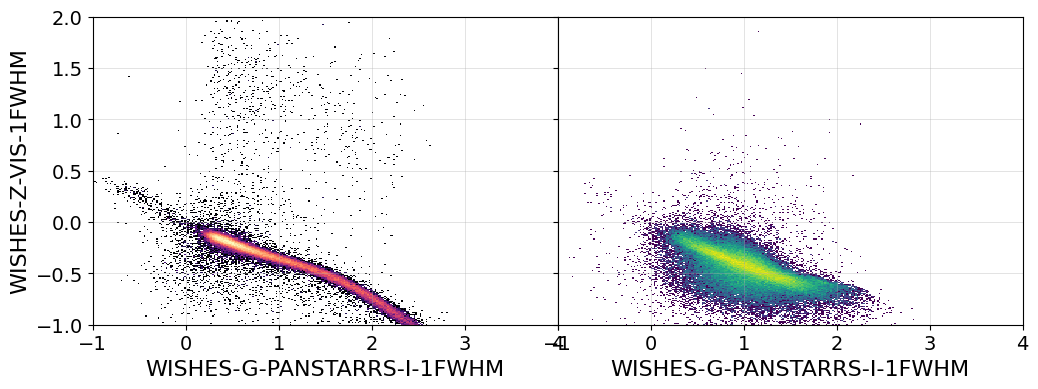

In [169]:
xmin, xmax = -1, 4
ymin, ymax = -1, 2
n_bins = 300
x_bins = np.linspace(xmin, xmax, n_bins + 1)
y_bins = np.linspace(ymin, ymax, n_bins + 1)
bins = (x_bins, y_bins)
x_color = 'WISHES-G-PANSTARRS-I_1FWHM'
y_color = 'WISHES-Z-VIS_1FWHM'
mask = df_sel['point_source_probability_mer'] <= .7
fig, axes = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(12, 4), gridspec_kw={'wspace': 0, 'hspace': 0})
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
mask = df_sel['point_source_probability_mer'] > .7
H, xedges, yedges = np.histogram2d(
    df_sel[x_color][mask], df_sel[y_color][mask], bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
# plt.title(f'{np.sum(mask)} sources > .7 PSP {np.sum(~mask)} sources < .7 PSP')
# plt.grid()
# plt.xlabel(x_color.replace('_', '-'))
# plt.ylabel(y_color.replace('_', '-
# '))
for ax in axes:
    ax.grid(True)
    ax.set_xlabel(x_color.replace('_', '-'))
# plt.xlim(-1.5, 2)
# plt.ylim(-1, 1)
axes[0].set_ylabel(y_color.replace('_', '-'))
# plt.savefig('psp_hist.png')
plt.show()

In [9]:
features = []
for FWHM in [1]:
    for i in range(len(bands)-1):
        for j in range(i+1, len(bands)):
            features.append(f'{bands[i]}-{bands[j]}_{FWHM}FWHM')
X = df_sel[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
print(len(X), len(df_sel))
print(features)

45022 45022
['CFIS-U-WISHES-G_1FWHM', 'CFIS-U-CFIS-R_1FWHM', 'CFIS-U-PANSTARRS-I_1FWHM', 'CFIS-U-WISHES-Z_1FWHM', 'CFIS-U-VIS_1FWHM', 'CFIS-U-NIR-Y_1FWHM', 'CFIS-U-NIR-J_1FWHM', 'CFIS-U-NIR-H_1FWHM', 'WISHES-G-CFIS-R_1FWHM', 'WISHES-G-PANSTARRS-I_1FWHM', 'WISHES-G-WISHES-Z_1FWHM', 'WISHES-G-VIS_1FWHM', 'WISHES-G-NIR-Y_1FWHM', 'WISHES-G-NIR-J_1FWHM', 'WISHES-G-NIR-H_1FWHM', 'CFIS-R-PANSTARRS-I_1FWHM', 'CFIS-R-WISHES-Z_1FWHM', 'CFIS-R-VIS_1FWHM', 'CFIS-R-NIR-Y_1FWHM', 'CFIS-R-NIR-J_1FWHM', 'CFIS-R-NIR-H_1FWHM', 'PANSTARRS-I-WISHES-Z_1FWHM', 'PANSTARRS-I-VIS_1FWHM', 'PANSTARRS-I-NIR-Y_1FWHM', 'PANSTARRS-I-NIR-J_1FWHM', 'PANSTARRS-I-NIR-H_1FWHM', 'WISHES-Z-VIS_1FWHM', 'WISHES-Z-NIR-Y_1FWHM', 'WISHES-Z-NIR-J_1FWHM', 'WISHES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']


In [10]:
Xn = StandardScaler().fit_transform(X)

In [11]:
embedding_2d = umap.UMAP(
    n_neighbors=50,
    min_dist=0
).fit_transform(Xn)

In [13]:
clusterer = HDBSCAN(
    min_cluster_size=1000,
    min_samples=50
)

labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([0, 1]), array([25158, 19864]))


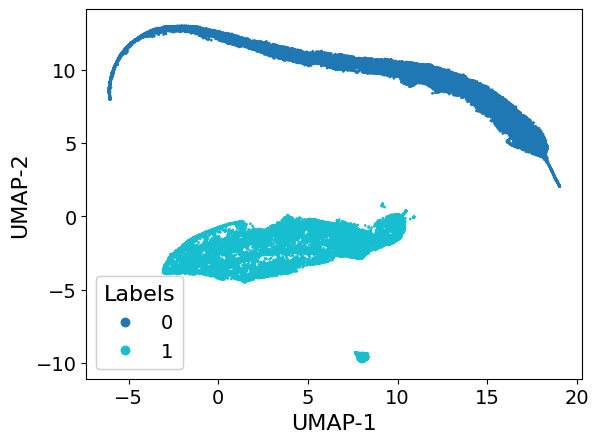

In [14]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.savefig('../../results/figures/analysis/UMAP_splitting_north.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/UMAP_splitting_north.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

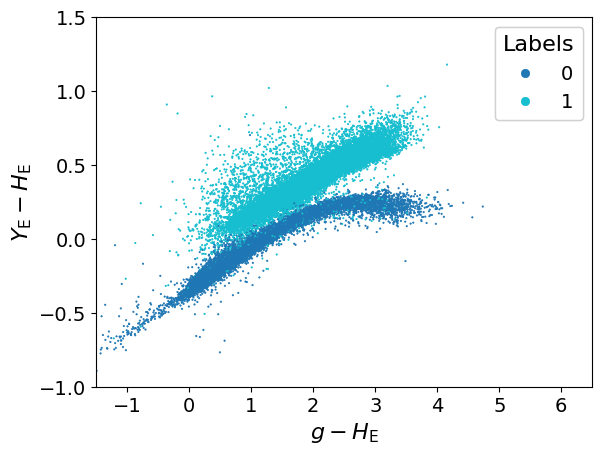

In [16]:
mask = labels != -1

scatter = plt.scatter(
    df_sel['WISHES-G-NIR-H_1FWHM'][mask],
    df_sel['NIR-Y-NIR-H_1FWHM'][mask],
    c=labels[mask],
    s=1,
    cmap='tab10',
    marker='o',
    linewidths=0.5,
    label='DBSCAN'
)

legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)

plt.xlabel(r'$g-H_\mathrm{E}$')
plt.ylabel(r'$Y_\mathrm{E}-H_\mathrm{E}$')
plt.xlim(-1.5, 6.5)
plt.ylim(-1, 1.5)
plt.savefig('../../results/figures/analysis/color_color_splitting_north.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/color_color_splitting_north.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

In [17]:
galaxy = df_sel[labels==1]
star = df_sel[labels==0]

In [18]:
pd.to_pickle(galaxy, 'galaxy_north.pkl')
pd.to_pickle(star, 'star_north.pkl')

In [3]:
galaxy =  pd.read_pickle('galaxy_north.pkl')
star =  pd.read_pickle('star_north.pkl')
bands = ['CFIS-U', 'WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']

In [4]:
selection = galaxy

In [5]:
for band in bands:
    selection[f'DELTA_FLUX_{band}_0'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_1FWHM'])/selection[f'FLUX_{band}_1FWHM']
    selection[f'DELTA_FLUX_{band}_1'] = (selection[f'FLUX_{band}_1FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']
    selection[f'DELTA_FLUX_{band}_2'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']

In [6]:
features = ['CFIS-U-WISHES-G_1FWHM', 'CFIS-U-CFIS-R_1FWHM', 'CFIS-U-PANSTARRS-I_1FWHM', 'CFIS-U-WISHES-Z_1FWHM', 'CFIS-U-VIS_1FWHM', 'CFIS-U-NIR-Y_1FWHM', 'CFIS-U-NIR-J_1FWHM', 'CFIS-U-NIR-H_1FWHM', 'WISHES-G-CFIS-R_1FWHM', 'WISHES-G-PANSTARRS-I_1FWHM', 'WISHES-G-WISHES-Z_1FWHM', 'WISHES-G-VIS_1FWHM', 'WISHES-G-NIR-Y_1FWHM', 'WISHES-G-NIR-J_1FWHM', 'WISHES-G-NIR-H_1FWHM', 'CFIS-R-PANSTARRS-I_1FWHM', 'CFIS-R-WISHES-Z_1FWHM', 'CFIS-R-VIS_1FWHM', 'CFIS-R-NIR-Y_1FWHM', 'CFIS-R-NIR-J_1FWHM', 'CFIS-R-NIR-H_1FWHM', 'PANSTARRS-I-WISHES-Z_1FWHM', 'PANSTARRS-I-VIS_1FWHM', 'PANSTARRS-I-NIR-Y_1FWHM', 'PANSTARRS-I-NIR-J_1FWHM', 'PANSTARRS-I-NIR-H_1FWHM', 'WISHES-Z-VIS_1FWHM', 'WISHES-Z-NIR-Y_1FWHM', 'WISHES-Z-NIR-J_1FWHM', 'WISHES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']
for band in bands:
    for i in range(3):
        features.append(f'DELTA_FLUX_{band}_{i}')

X = selection[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
Xn = StandardScaler().fit_transform(X)

In [7]:
embedding_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.0
).fit_transform(Xn)

In [8]:
clusterer = HDBSCAN(min_cluster_size=50,
                    min_samples=10, n_jobs=5)
clusterer = DBSCAN(eps=0.19, min_samples=5)

# labels = clusterer.fit_predict(embedding_2d)
# labels[labels == 1] = 1000
labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([   27, 18014,  1143,     6,     6,   453,    70,    43,    21,
          37,    44]))


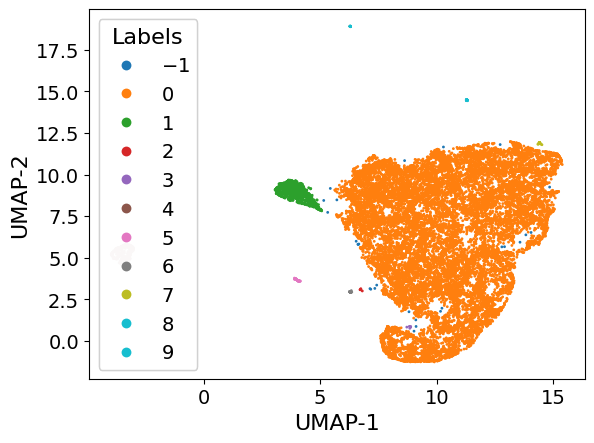

In [9]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.savefig('../../results/figures/analysis/UMAP_galaxy_north.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/UMAP_galaxy_north.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

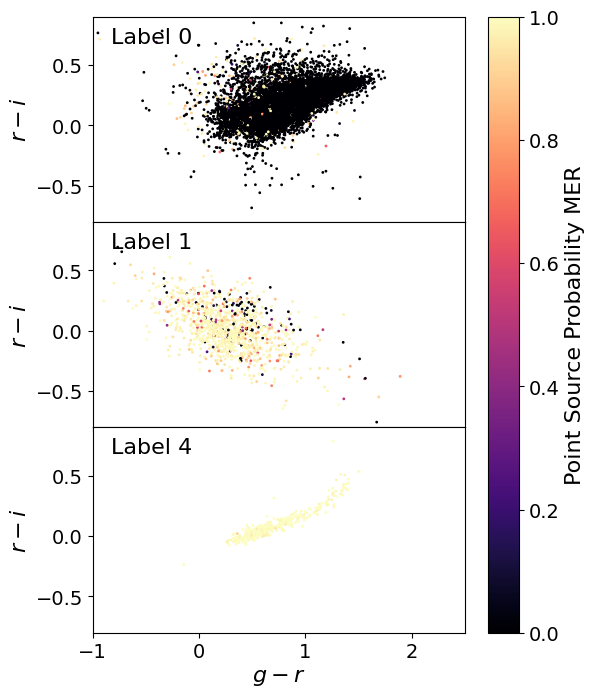

In [10]:
mask = labels == 0
x_color = 'WISHES-G-CFIS-R_1FWHM'
y_color = 'CFIS-R-PANSTARRS-I_1FWHM'

fig, axes = plt.subplots(3,1, sharey=True, sharex=True, figsize=(6,8), gridspec_kw={'wspace': 0, 'hspace': 0})

x_min, x_max = -1, 2.5
y_min, y_max = -0.8, 0.9
for i, label in enumerate([0, 1, 4]):
    mask = labels == label
    sc1  = axes[i].scatter(
        galaxy[x_color][mask],
        galaxy[y_color][mask],
        c=galaxy['point_source_probability_mer'][mask],
        vmin=0, vmax=1,
        s=1,
        marker='o',
        label='DBSCAN'
    )
    axes[i].text(
    0.05, 0.95, f"Label {label}",
    transform=axes[i].transAxes,
    va="top"
)
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
axes[-1].set_xlabel(r"$g-r$")
fig.colorbar(sc1, ax=axes, label="Point Source Probability MER")
# plt.savefig('../../results/figures/analysis/color_color_galaxy_north.pdf', bbox_inches="tight", pad_inches=0)
# plt.savefig('../../results/figures/analysis/color_color_galaxy_north.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

In [11]:
star_like = selection[labels==4]
galaxy = selection[labels == 0]
quasar = selection[labels == 1]

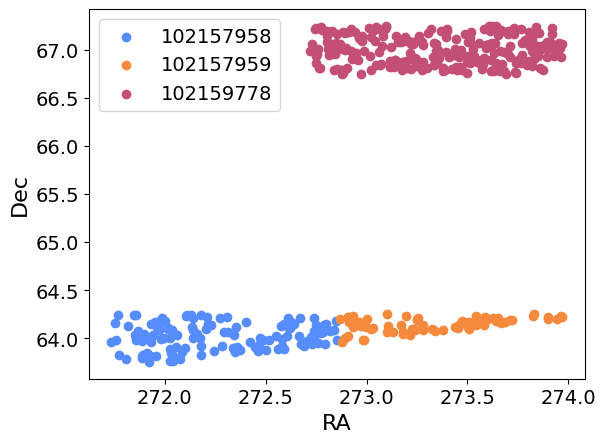

In [35]:
# plt.figure(figsize=(15,10))
plt.scatter(star_like['ra'][star_like['tile_index'] == 102157958], star_like['dec'][star_like['tile_index'] == 102157958], label='102157958')
# plt.xlim(np.nanmin(galaxy['ra'][galaxy['tile_index'] == 102157958]), np.nanmax(galaxy['ra'][galaxy['tile_index'] == 102157958]))
# plt.ylim(np.nanmin(galaxy['dec'][galaxy['tile_index'] == 102157958]), np.nanmax(galaxy['dec'][galaxy['tile_index'] == 102157958]))
plt.scatter(star_like['ra'][star_like['tile_index'] == 102157959], star_like['dec'][star_like['tile_index'] == 102157959], label='102157959')
plt.scatter(star_like['ra'][star_like['tile_index'] == 102159778], star_like['dec'][star_like['tile_index'] == 102159778], label='102159778')
plt.legend()
plt.xlabel("RA")
plt.ylabel("Dec")
plt.show()

In [36]:
sel = galaxy.sort_values(by='FWHM').iloc[:1000]
sel = star_like.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), *tileindex, len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == 102157959.0]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")
ds9_regions(coords[coords[:, 0] == 102157958], 5)

3 102157958.0 102157959.0 102159778.0 452
102159778.0 248
np.array([
    (272.880361, 63.964243),
    (272.983148, 63.980080),
    (272.989073, 63.983190),
    (272.891591, 63.998696),
    (272.910562, 64.021625),
    (273.213144, 64.028352),
    (273.183298, 64.044720),
    (273.103398, 64.059621),
    (273.133731, 64.062293),
    (273.181858, 64.067526),
    (273.341944, 64.069910),
    (273.381214, 64.085105),
    (273.239376, 64.085535),
    (273.279314, 64.087081),
    (273.226240, 64.090286),
    (273.234543, 64.090857),
    (273.325423, 64.092895),
    (273.024168, 64.097539),
    (273.509227, 64.100034),
    (273.454714, 64.101942),
    (273.031047, 64.103500),
    (272.932452, 64.112186),
    (273.437671, 64.113400),
    (272.998756, 64.113235),
    (273.501925, 64.114312),
    (273.448245, 64.115056),
    (273.274116, 64.116682),
    (272.975105, 64.123200),
    (273.105580, 64.130748),
    (273.457220, 64.131978),
    (273.540543, 64.132889),
    (273.282395, 64.133780),
   

In [14]:
group = star_like
other = galaxy
group_mean = group.mean(axis=0)
rest_mean = other.mean(axis=0)

global_std = selection.std(axis=0)

delta = (group_mean - rest_mean) / global_std

importance = pd.Series(
    delta,
    index=features
).sort_values(key=np.abs, ascending=False)

print(importance)

DELTA_FLUX_WISHES-Z_2         6.239200
PANSTARRS-I-WISHES-Z_1FWHM   -5.640657
DELTA_FLUX_WISHES-Z_0         5.575533
WISHES-Z-VIS_1FWHM            5.525473
WISHES-Z-NIR-Y_1FWHM          5.361691
                                ...   
CFIS-U-NIR-H_1FWHM           -0.363090
PANSTARRS-I-VIS_1FWHM         0.351377
WISHES-G-CFIS-R_1FWHM        -0.341262
CFIS-U-NIR-Y_1FWHM            0.108226
CFIS-U-NIR-J_1FWHM           -0.084551
Length: 63, dtype: float64


In [15]:
sel = galaxy.sort_values(by='FWHM').iloc[:1000]
sel = galaxy.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

111 18013
102158889.0 527
np.array([
    (267.888494, 65.249078),
    (267.878571, 65.248621),
    (267.914117, 65.249849),
    (267.289328, 65.253500),
    (267.809184, 65.254388),
    (267.692782, 65.255731),
    (266.855711, 65.255343),
    (267.788935, 65.255898),
    (267.005227, 65.257375),
    (267.761439, 65.259676),
    (267.695366, 65.260774),
    (267.679061, 65.262567),
    (267.786088, 65.262482),
    (267.092360, 65.268073),
    (267.145662, 65.268627),
    (267.958639, 65.267921),
    (267.801946, 65.268684),
    (267.766213, 65.270017),
    (267.312631, 65.271245),
    (267.417273, 65.272598),
    (267.261470, 65.275721),
    (267.146571, 65.277945),
    (267.235543, 65.278545),
    (267.171225, 65.279545),
    (267.394219, 65.281758),
    (267.722929, 65.281667),
    (267.036802, 65.284067),
    (267.370821, 65.285239),
    (267.763053, 65.285512),
    (267.066300, 65.286762),
    (267.067092, 65.286970),
    (267.360330, 65.287814),
    (266.939044, 65.287564),
    (2

In [16]:
sel = galaxy.sort_values(by='FWHM').iloc[:1000]
sel = quasar.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == 102157958]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

97 1142
102159484.0 26
np.array([
    (272.509703, 63.886697),
    (272.376744, 63.903600),
    (272.444216, 64.121654),
])


In [17]:
selection = star

In [18]:
for band in bands:
    selection[f'DELTA_FLUX_{band}_0'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_1FWHM'])/selection[f'FLUX_{band}_1FWHM']
    selection[f'DELTA_FLUX_{band}_1'] = (selection[f'FLUX_{band}_1FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']
    selection[f'DELTA_FLUX_{band}_2'] = (selection[f'FLUX_{band}_0.5FWHM'] - selection[f'FLUX_{band}_2FWHM'])/selection[f'FLUX_{band}_2FWHM']

In [19]:
features = ['CFIS-U-WISHES-G_1FWHM', 'CFIS-U-CFIS-R_1FWHM', 'CFIS-U-PANSTARRS-I_1FWHM', 'CFIS-U-WISHES-Z_1FWHM', 'CFIS-U-VIS_1FWHM', 'CFIS-U-NIR-Y_1FWHM', 'CFIS-U-NIR-J_1FWHM', 'CFIS-U-NIR-H_1FWHM', 'WISHES-G-CFIS-R_1FWHM', 'WISHES-G-PANSTARRS-I_1FWHM', 'WISHES-G-WISHES-Z_1FWHM', 'WISHES-G-VIS_1FWHM', 'WISHES-G-NIR-Y_1FWHM', 'WISHES-G-NIR-J_1FWHM', 'WISHES-G-NIR-H_1FWHM', 'CFIS-R-PANSTARRS-I_1FWHM', 'CFIS-R-WISHES-Z_1FWHM', 'CFIS-R-VIS_1FWHM', 'CFIS-R-NIR-Y_1FWHM', 'CFIS-R-NIR-J_1FWHM', 'CFIS-R-NIR-H_1FWHM', 'PANSTARRS-I-WISHES-Z_1FWHM', 'PANSTARRS-I-VIS_1FWHM', 'PANSTARRS-I-NIR-Y_1FWHM', 'PANSTARRS-I-NIR-J_1FWHM', 'PANSTARRS-I-NIR-H_1FWHM', 'WISHES-Z-VIS_1FWHM', 'WISHES-Z-NIR-Y_1FWHM', 'WISHES-Z-NIR-J_1FWHM', 'WISHES-Z-NIR-H_1FWHM', 'VIS-NIR-Y_1FWHM', 'VIS-NIR-J_1FWHM', 'VIS-NIR-H_1FWHM', 'NIR-Y-NIR-J_1FWHM', 'NIR-Y-NIR-H_1FWHM', 'NIR-J-NIR-H_1FWHM']
for band in bands:
    for i in range(3):
        features.append(f'DELTA_FLUX_{band}_{i}')

X = selection[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
Xn = StandardScaler().fit_transform(X)

In [20]:
embedding_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.0
).fit_transform(Xn)

In [21]:
clusterer = HDBSCAN(min_cluster_size=500,
                    min_samples=10, n_jobs=5)
# clusterer = DBSCAN(eps=0.3)

# labels = clusterer.fit_predict(embedding_2d)
# labels[labels == 1] = 1000
labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([0, 1]), array([24106,  1052]))


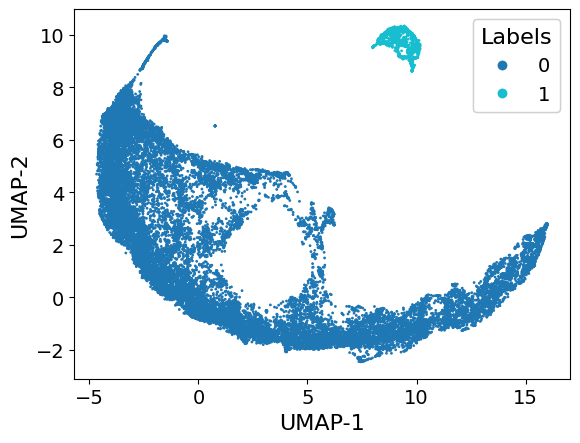

In [22]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10',
    rasterized=True
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)
plt.savefig('../../results/figures/analysis/UMAP_star_north.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/UMAP_star_north.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

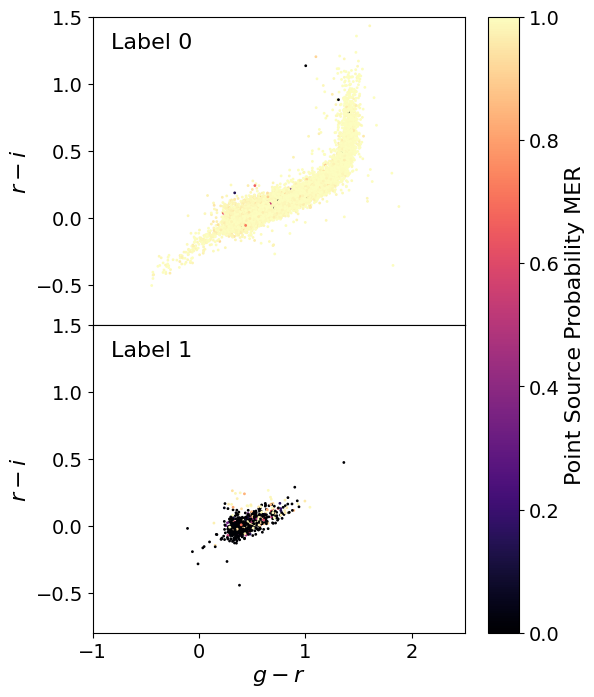

In [23]:
mask = labels == 0
x_color = 'WISHES-G-CFIS-R_1FWHM'
y_color = 'CFIS-R-PANSTARRS-I_1FWHM'

fig, axes = plt.subplots(2,1, sharey=True, sharex=True, figsize=(6,8), gridspec_kw={'wspace': 0, 'hspace': 0})

x_min, x_max = -1, 2.5
y_min, y_max = -0.8, 1.5
for i in range(2):
    mask = labels == i
    sc1  = axes[i].scatter(
        selection[x_color][mask],
        selection[y_color][mask],
        c=selection['point_source_probability_mer'][mask],
        vmin=0, vmax=1,
        s=1,
        marker='o',
        label='DBSCAN'
    )
    axes[i].text(
    0.05, 0.95, f"Label {i}",
    transform=axes[i].transAxes,
    va="top"
)
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(r"$r-i$")
axes[-1].set_xlabel(r"$g-r$")
fig.colorbar(sc1, ax=axes, label="Point Source Probability MER")
plt.savefig('../../results/figures/analysis/color_color_star_north.pdf', bbox_inches="tight", pad_inches=0)
plt.savefig('../../results/figures/analysis/color_color_star_north.jpg', bbox_inches="tight", pad_inches=0)
plt.show()

In [24]:
extended_star = star[labels==1]
not_extended_star = star[labels==0]

In [25]:
sel = extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

97 1051
102160063.0 31
np.array([
    (274.749950, 67.252568),
    (275.222359, 67.259737),
    (275.039792, 67.287124),
    (274.792398, 67.286938),
    (274.793943, 67.287596),
    (275.264818, 67.305663),
    (274.563444, 67.320804),
    (274.918806, 67.327054),
    (275.515444, 67.327609),
    (275.622314, 67.368195),
    (275.622982, 67.368213),
    (275.354902, 67.380435),
    (275.339297, 67.387174),
    (275.600201, 67.388079),
    (274.714089, 67.412362),
    (274.524091, 67.452957),
    (275.107087, 67.461309),
    (274.514540, 67.467275),
    (274.826254, 67.470852),
    (274.675967, 67.494380),
    (274.815899, 67.539186),
    (274.493953, 67.593438),
    (274.572393, 67.619576),
    (274.869951, 67.621907),
    (274.868818, 67.621953),
])


In [26]:
sel = not_extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 100
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

112 24105
102158895.0 583
np.array([
    (274.491566, 65.248852),
    (274.998567, 65.249200),
    (274.542038, 65.254692),
    (275.016399, 65.253983),
    (274.934705, 65.254248),
    (274.544248, 65.255179),
    (274.808507, 65.256057),
    (274.545570, 65.256385),
    (274.472544, 65.256571),
    (274.129914, 65.256186),
    (274.595741, 65.258488),
    (274.611493, 65.259568),
    (274.653344, 65.264160),
    (273.958376, 65.264978),
    (274.730828, 65.266516),
    (274.949070, 65.267091),
    (274.750477, 65.268533),
    (274.776804, 65.270545),
    (274.703371, 65.273277),
    (273.910716, 65.273466),
    (273.913948, 65.273443),
    (274.021267, 65.276777),
    (275.051854, 65.278425),
    (273.935005, 65.278792),
    (275.027934, 65.279377),
    (275.031505, 65.279991),
    (273.946907, 65.280334),
    (275.023124, 65.281698),
    (274.707237, 65.283614),
    (274.847206, 65.283789),
    (273.917533, 65.283590),
    (274.211609, 65.285196),
    (274.743029, 65.287659),
    (2

In [27]:
pd.to_pickle(quasar, 'classes/quasar_north.pkl')
pd.to_pickle(galaxy, 'classes/non_quasar_north.pkl')
pd.to_pickle(extended_star, 'classes/extended_star_north.pkl')
pd.to_pickle(not_extended_star, 'classes/not_extended_star_north.pkl')
pd.to_pickle(star_like, 'classes/star_like_north.pkl')

### JUST ANALYZING THE CLASSES

In [7]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob
from astropy.io import fits
from astropy.table import Table

In [2]:
def ds9_regions(coords, opening=5):
    with open("D:\ds9_new.reg", "w") as f:
        f.write("# Region file format: DS9 version 4.1\n")
        f.write("global color=green\n")
        f.write("fk5\n")
        for i, (_, x, y) in enumerate(coords):
            f.write(f'circle({x},{y},{opening}")\n')
            f.write(f'circle({x},{y},{opening/100}")\n')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_6448\2020934162.py:2: SyntaxWarning: invalid escape sequence '\d'
  with open("D:\ds9_new.reg", "w") as f:


In [3]:
quasar = pd.read_pickle('classes/quasar_north.pkl')
galaxy = pd.read_pickle('classes/non_quasar_north.pkl')
extended_star = pd.read_pickle('classes/extended_star_north.pkl')
not_extended_star = pd.read_pickle('classes/not_extended_star_north.pkl')
star_like = pd.read_pickle('classes/star_like_north.pkl')

In [4]:
sel = extended_star.iloc[:-1]
coords = sel[['tile_index', "ra", "dec"]].to_numpy()
tileindex, counts = np.unique(coords[:, 0], return_counts=True)
print(len(tileindex), len(sel))
print(tileindex[np.argmax(counts)], np.max(counts))
# coords
num_of_objects = 25
print("np.array([")
for i, (_, x, y) in enumerate(coords[coords[:, 0] == tileindex[np.argmax(counts)]]):
    if i > num_of_objects - 1:
        break
    print(f"    ({x:.6f}, {y:.6f}),")
print("])")

97 1051
102160063.0 31
np.array([
    (274.749950, 67.252568),
    (275.222359, 67.259737),
    (275.039792, 67.287124),
    (274.792398, 67.286938),
    (274.793943, 67.287596),
    (275.264818, 67.305663),
    (274.563444, 67.320804),
    (274.918806, 67.327054),
    (275.515444, 67.327609),
    (275.622314, 67.368195),
    (275.622982, 67.368213),
    (275.354902, 67.380435),
    (275.339297, 67.387174),
    (275.600201, 67.388079),
    (274.714089, 67.412362),
    (274.524091, 67.452957),
    (275.107087, 67.461309),
    (274.514540, 67.467275),
    (274.826254, 67.470852),
    (274.675967, 67.494380),
    (274.815899, 67.539186),
    (274.493953, 67.593438),
    (274.572393, 67.619576),
    (274.869951, 67.621907),
    (274.868818, 67.621953),
])


In [5]:
df_total = pd.read_pickle('../../all_fluxes_north.pkl')

In [ ]:
mask = (df_total['tile_index'] == 102157958) | (df_total['tile_index'] == 102157959) | (df_total['tile_index'] == 102159778)
weird_tiles = df_total[mask]
weird_tiles = weird_tiles[~np.isnan(weird_tiles)]
normal_tiles = df_total[~mask]
normal_tiles = normal_tiles[~np.isnan(normal_tiles)]

FLUX_NIR-H_0.5FWHM -0.021505184150418705


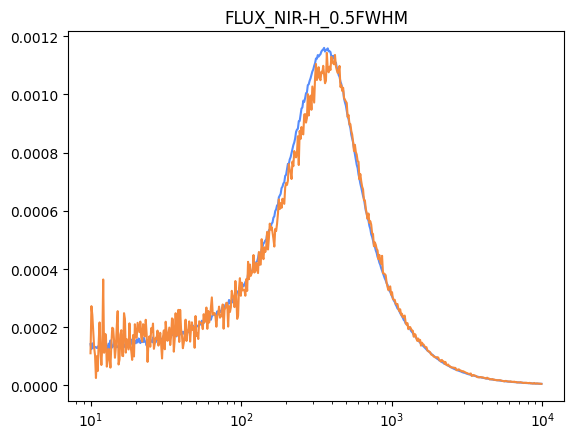

FLUX_CFIS-R_0.5FWHM -0.08104895188563614


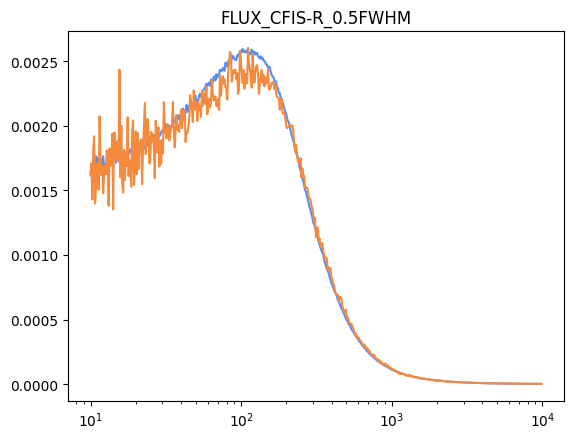

FLUX_NIR-Y_0.5FWHM -0.02652411453756064


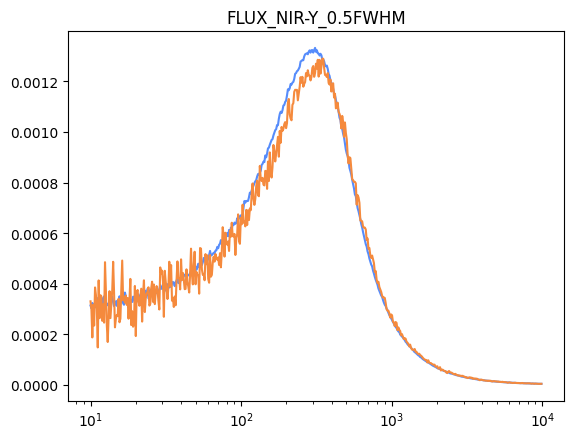

FLUX_CFIS-U_0.5FWHM -0.1865899049126597


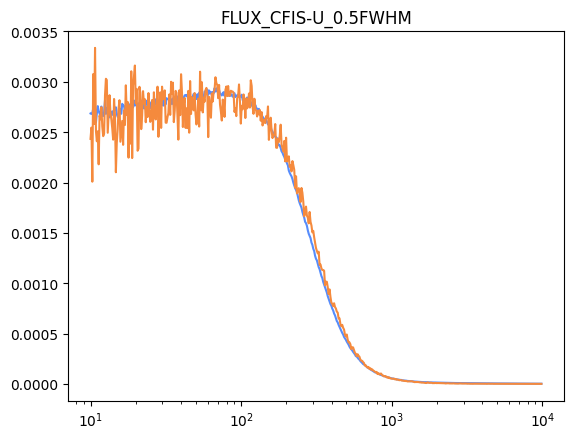

FLUX_NIR-J_0.5FWHM -0.033355074490117514


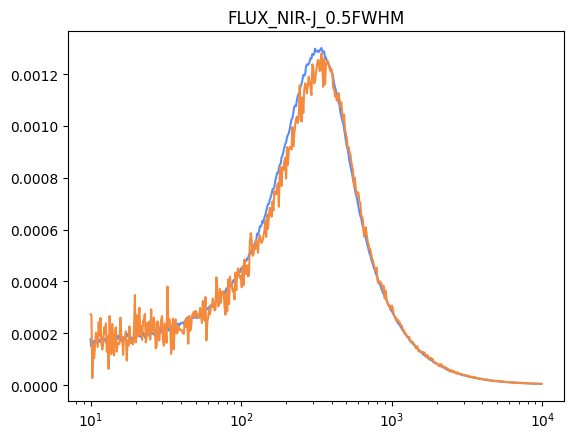

FLUX_PANSTARRS-I_0.5FWHM -0.019241929628786538


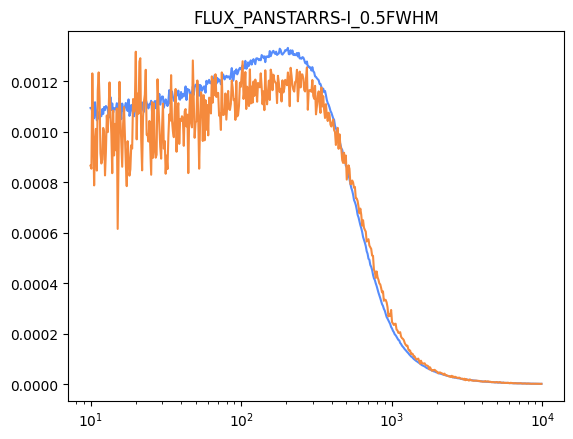

FLUX_VIS_0.5FWHM -0.006848215965725704


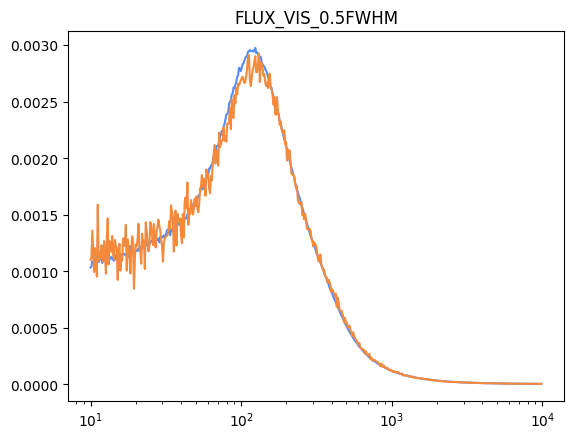

FLUX_WISHES-Z_0.5FWHM -8.773268222009868


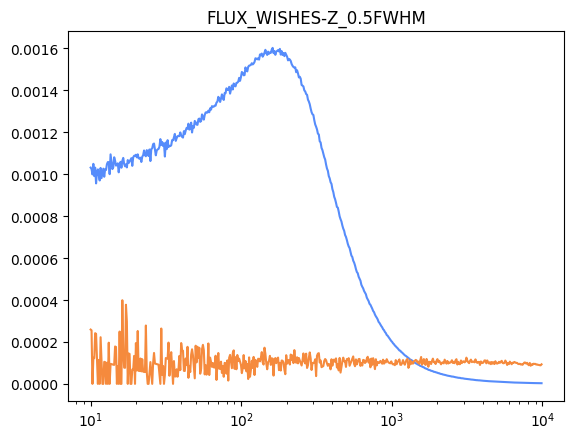

FLUX_WISHES-G_0.5FWHM 0.010697817051414137


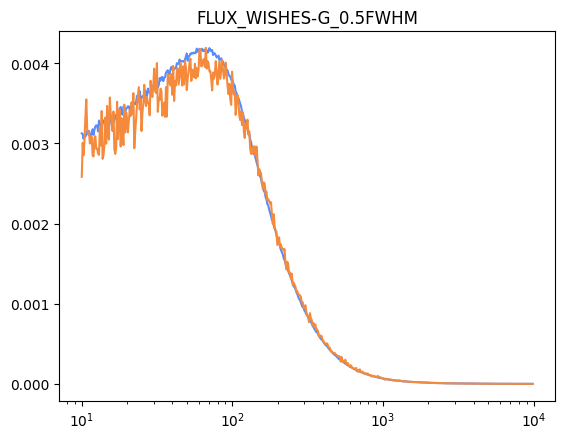

FLUX_NIR-J_1FWHM -0.03634320927530197


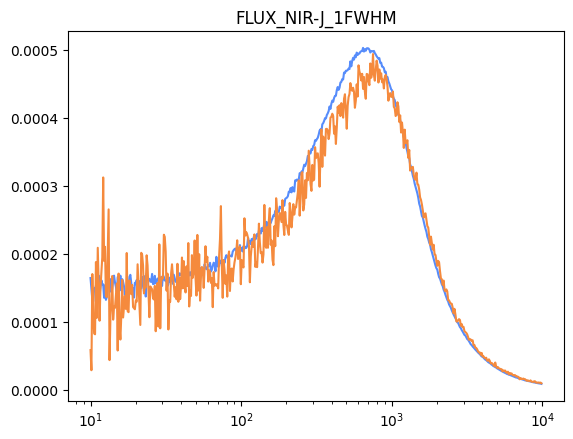

FLUX_CFIS-U_1FWHM -0.054653188917316166


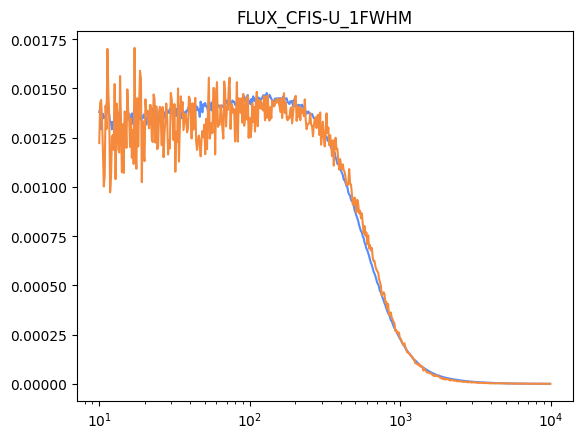

FLUX_NIR-H_1FWHM -0.02453371538046315


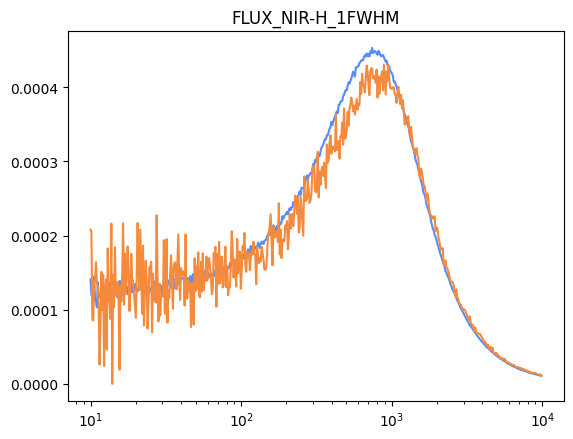

FLUX_CFIS-R_1FWHM -0.049339142245331084


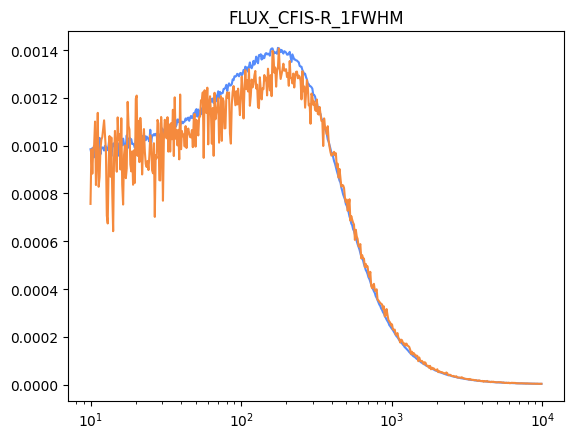

FLUX_NIR-Y_1FWHM -0.028670561074852944


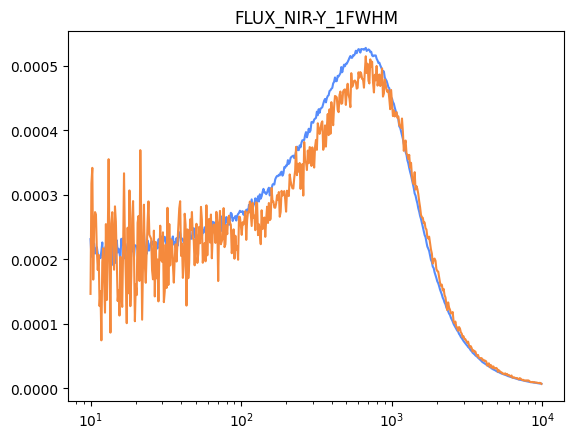

FLUX_WISHES-Z_1FWHM 0.6453427196957118


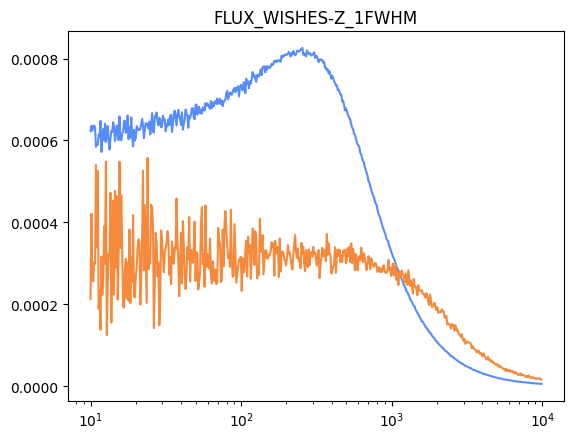

FLUX_PANSTARRS-I_1FWHM -0.0018136837526216846


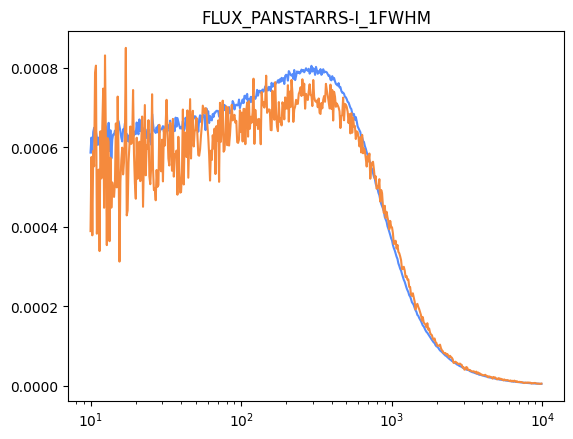

FLUX_WISHES-G_1FWHM 0.010429449499731605


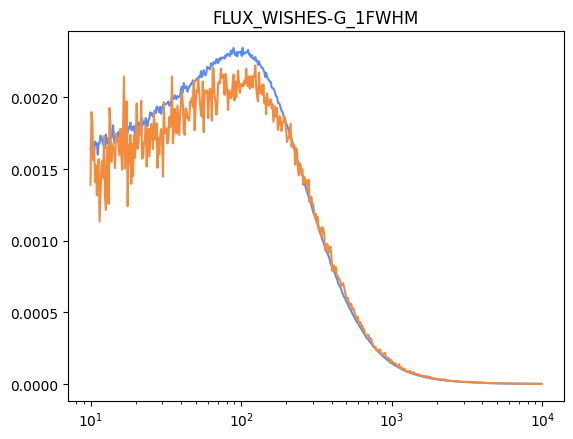

FLUX_VIS_1FWHM 0.004148367103703486


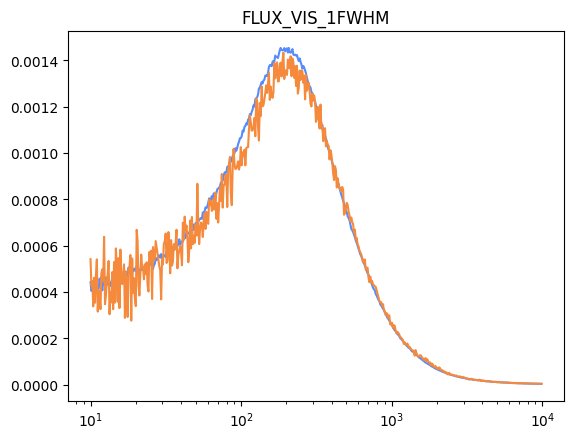

FLUX_NIR-J_2FWHM -0.06424515921830178


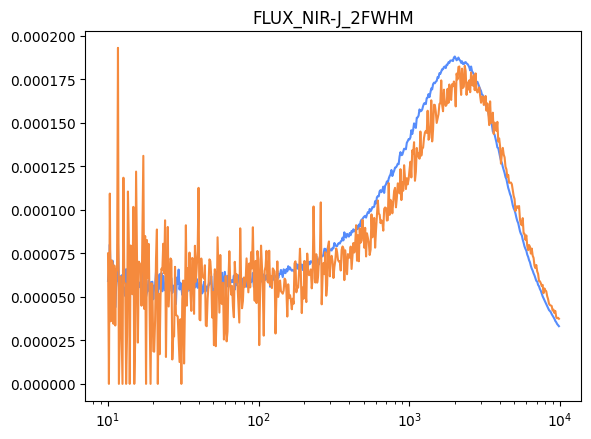

FLUX_NIR-Y_2FWHM -0.0588380587306242


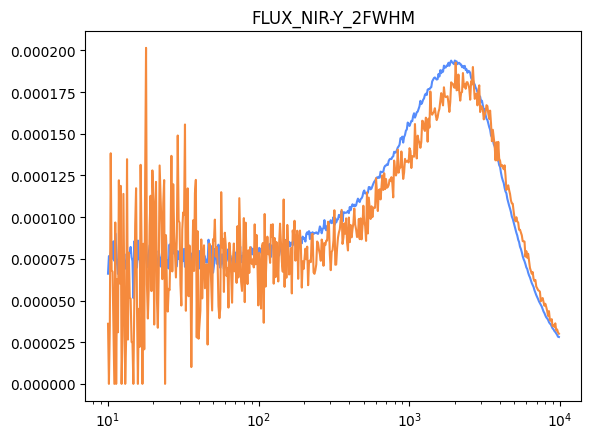

FLUX_NIR-H_2FWHM -0.05416272751427437


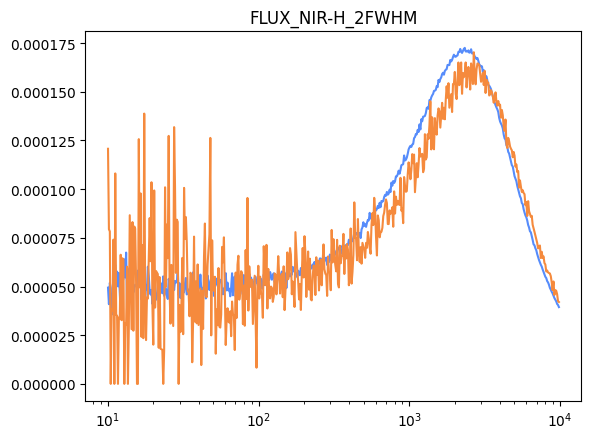

FLUX_CFIS-U_2FWHM 0.02722532883373843


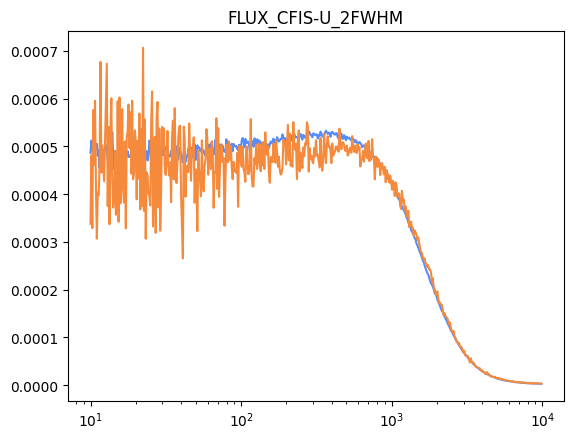

FLUX_CFIS-R_2FWHM -0.0019883780598427994


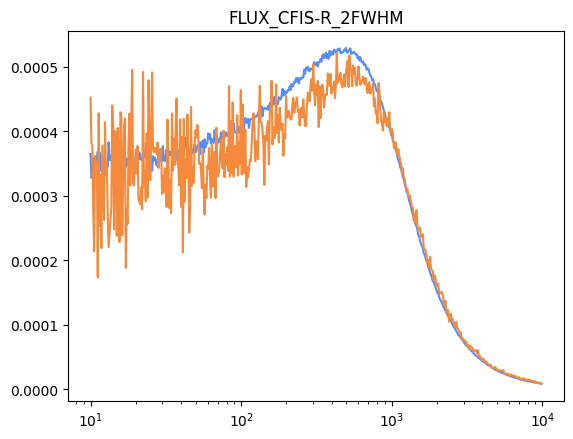

FLUX_WISHES-G_2FWHM -0.023836869056293678


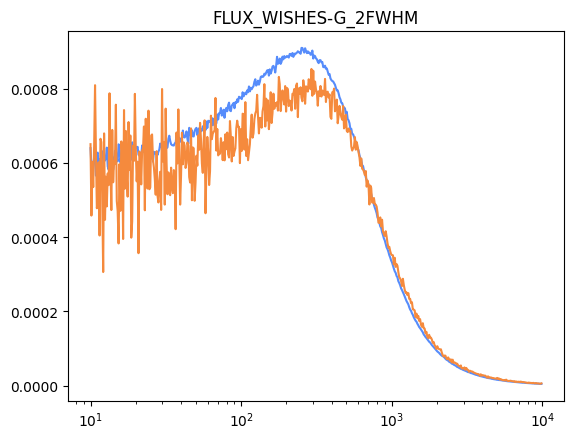

FLUX_PANSTARRS-I_2FWHM 0.021631990157059543


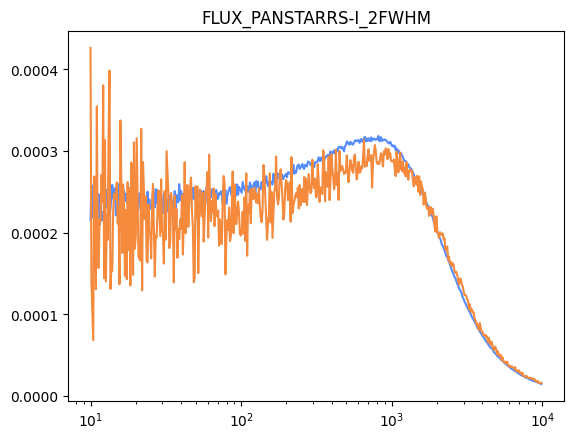

FLUX_WISHES-Z_2FWHM -0.2673961237706105


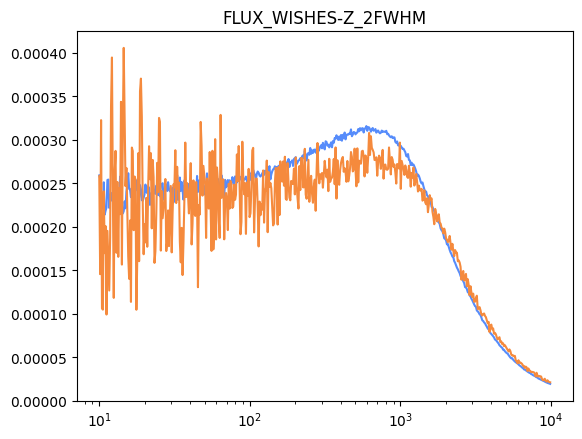

FLUX_VIS_2FWHM -0.010486146637659063


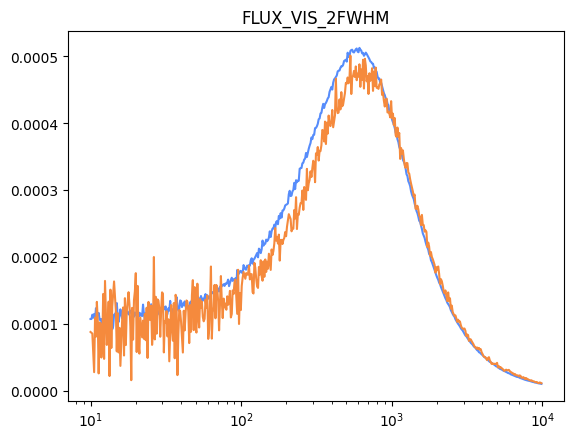

In [9]:
for column in normal_tiles.columns:
    if 'ERR' not in column and 'FLUX' in column:
        print(column, (np.nanmean(normal_tiles[column]) - np.nanmean(weird_tiles[column]))/np.nanmean(normal_tiles[column]))
        # if 'WISHES-Z' in column:
        plt.title(column)
        bins = np.logspace(1, 4, 500)

        counts, edges = np.histogram(normal_tiles[column][normal_tiles[column]>0], bins=bins)
        bin_widths = np.diff(edges)

        density = counts / (counts.sum() * bin_widths)

        plt.plot(edges[:-1], density)
        counts, edges = np.histogram(weird_tiles[column][weird_tiles[column]>0], bins=bins)
        bin_widths = np.diff(edges)

        density = counts / (counts.sum() * bin_widths)

        plt.plot(edges[:-1], density)
        plt.xscale('log')
        plt.show()

In [12]:
file = glob.glob("C:/catalog_files/EUC_PHZ_CLASSCAT__20241120T094730.789055Z_00.00.fits")[0]
with fits.open(file, memmap=True) as hdul:
    cat = Table(hdul[1].data)

In [13]:
cat = cat.to_pandas()

In [88]:
cat

,OBJECT_ID,CONFIGURATION,PHZ_STAR_PROB,PHZ_GAL_PROB,PHZ_QSO_PROB,PHZ_GLOB_CL_PROB,PHZ_CLASSIFICATION,VIS_DET,MISSING_BAND,STAR_THRESHOLD,GALAXY_THRESHOLD,QSO_THRESHOLD,GLOBC_THRESHOLD
0,2648390189672483539,30,0.033203,0.880231,0.125478,0.0,2,1,,0.58143,0.220495,0.668687,1.0
1,2649075306672483804,30,0.010800,0.861878,0.114972,0.0,2,1,,0.58143,0.220495,0.668687,1.0
2,2647266964672485757,30,0.030851,0.017579,0.784195,0.0,4,1,,0.58143,0.220495,0.668687,1.0
3,2650669033672485962,30,0.052425,0.803199,0.157379,0.0,2,1,,0.58143,0.220495,0.668687,1.0
4,2650443258672488852,30,0.002532,0.896345,0.074589,0.0,2,1,,0.58143,0.220495,0.668687,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107633,2651620982677535386,30,0.007540,0.798952,0.202030,0.0,2,0,,0.58143,0.220495,0.668687,1.0
107634,2654188962677532401,30,0.012202,0.535755,0.495342,0.0,2,0,,0.58143,0.220495,0.668687,1.0
107635,2654430066677531830,30,0.024226,0.710270,0.284598,0.0,2,0,,0.58143,0.220495,0.668687,1.0
107636,2653929961677533920,30,0.021887,0.648327,0.414732,0.0,2,0,,0.58143,0.220495,0.668687,1.0


In [89]:
quasar

,id,tile_index,ra,dec,FWHM,point_source_probability_mer,FLUX_NIR-H_0.5FWHM,FLUXERR_NIR-H_0.5FWHM,FLUX_CFIS-R_0.5FWHM,FLUXERR_CFIS-R_0.5FWHM,...,DELTA_FLUX_VIS_2,DELTA_FLUX_NIR-Y_0,DELTA_FLUX_NIR-Y_1,DELTA_FLUX_NIR-Y_2,DELTA_FLUX_NIR-J_0,DELTA_FLUX_NIR-J_1,DELTA_FLUX_NIR-J_2,DELTA_FLUX_NIR-H_0,DELTA_FLUX_NIR-H_1,DELTA_FLUX_NIR-H_2
247,2682942266682534905,102160607,268.294227,68.253491,1.228482,0.983411,118095.509464,2408.677232,66472.441182,196.179655,...,-0.071654,-0.067021,-0.043985,-0.108058,-0.073135,-0.063033,-0.131557,-0.090789,-0.069841,-0.154289
2553,2681859932682662487,102160607,268.185993,68.266249,1.276519,0.721373,97529.442775,1841.599035,17352.159183,198.190848,...,-0.146805,-0.150887,-0.065495,-0.206500,-0.154831,-0.092502,-0.233011,-0.167278,-0.087422,-0.240076
6963,2684310759682928582,102160607,268.431076,68.292858,1.293386,0.990257,53586.912948,1498.718021,23659.432145,229.561593,...,-0.056576,-0.055973,-0.044511,-0.097992,-0.040669,-0.023738,-0.063441,-0.064222,-0.052660,-0.113500
8186,2680001731683001430,102160607,268.000173,68.300143,1.291140,0.819485,15722.418893,996.502094,7680.220576,263.022274,...,-0.256109,-0.195938,-0.244883,-0.392839,-0.179652,-0.225198,-0.364393,-0.182803,-0.232587,-0.372872
12574,2681506679683279815,102160607,268.150668,68.327982,1.208509,0.992807,68673.592635,1661.546859,43621.910799,171.935819,...,-0.086100,-0.070054,-0.065084,-0.130579,-0.061980,-0.079402,-0.136461,-0.075484,-0.108061,-0.175388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11305195,2738426260650247231,102158589,273.842626,65.024723,1.355969,0.979046,35218.907760,1502.139196,31863.415255,322.174695,...,-0.081134,-0.122945,-0.149736,-0.254271,-0.119547,-0.124823,-0.229448,-0.126205,-0.126927,-0.237113
11307852,2740802397650405033,102158589,274.080240,65.040503,1.358287,0.998449,95673.116976,2617.548791,98431.824237,314.986435,...,-0.055045,-0.048429,-0.038970,-0.085512,-0.058750,-0.042884,-0.099114,-0.059118,-0.036657,-0.093608
11333377,2743058148651776780,102158589,274.305815,65.177678,1.308891,0.990090,22141.426058,1221.827892,15080.152183,212.602815,...,-0.075103,-0.051047,-0.004168,-0.055001,-0.042643,-0.041693,-0.082559,-0.081494,-0.085532,-0.160056
11339486,2744650072652106508,102158589,274.465007,65.210651,1.328038,0.871035,52069.536991,1721.395106,19186.398963,389.321104,...,-0.173004,-0.165347,-0.115247,-0.261538,-0.154365,-0.094413,-0.234203,-0.165846,-0.101641,-0.250630


In [14]:
matches = cat[cat['OBJECT_ID'].isin(galaxy['id'])]
matches

,OBJECT_ID,CONFIGURATION,PHZ_STAR_PROB,PHZ_GAL_PROB,PHZ_QSO_PROB,PHZ_GLOB_CL_PROB,PHZ_CLASSIFICATION,VIS_DET,MISSING_BAND,STAR_THRESHOLD,GALAXY_THRESHOLD,QSO_THRESHOLD,GLOBC_THRESHOLD
7,2649098724672490238,30,0.002224,0.970240,0.015764,0.0,2,1,,0.58143,0.220495,0.668687,1.0
529,2644110952672535328,30,0.003248,0.618302,0.407140,0.0,2,1,,0.58143,0.220495,0.668687,1.0
1110,2649979123672575782,30,0.002216,0.970240,0.013929,0.0,2,1,,0.58143,0.220495,0.668687,1.0
1501,2643586519672591763,30,0.002220,0.970240,0.013929,0.0,2,1,,0.58143,0.220495,0.668687,1.0
1703,2644790629672611173,30,0.002246,0.970265,0.013929,0.0,2,1,,0.58143,0.220495,0.668687,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77985,2653296204677412399,30,0.005118,0.659313,0.111730,0.0,2,1,,0.58143,0.220495,0.668687,1.0
78121,2649636394677439392,30,0.002320,0.970240,0.013929,0.0,2,1,,0.58143,0.220495,0.668687,1.0
78236,2652293231677449754,30,0.002225,0.970240,0.014232,0.0,2,1,,0.58143,0.220495,0.668687,1.0
78280,2653297334677474265,30,0.002843,0.804486,0.064696,0.0,2,1,,0.58143,0.220495,0.668687,1.0
